# Sentiment Analysis
## Marissa Burton

### Load in packages

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob, Blobber
import os
import matplotlib.pyplot as plt
import seaborn as sns

### Load in tables

In [11]:
OHCO = ['era', 'book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
VOCAB = pd.read_csv('data/VOCAB.csv')
BOW = pd.read_csv('data/BOW.csv')
CORPUS = pd.read_csv('data/CORPUS.csv').set_index(OHCO).sort_index()
LIB = pd.read_csv('data/LIB.csv').set_index('book_id').sort_index()
GI_raw = pd.read_excel('data/inquirerbasic.xls')

/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_60610/2661224481.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  CORPUS = pd.read_csv('data/CORPUS.csv').set_index(OHCO).sort_index()


In [19]:
VOCAB

,term_str,n,n_chars,p,i,max_pos,max_pos_group,stop,stem_porter,df,idf,dfidf,tfidf_mean,ngram_length
0,000,1,3,0.000002,19.295966,CD,CD,0,000,1,6.965784,6.965784,0.055726,3
1,1,31,1,0.000048,14.341770,NN,NN,0,1,18,2.795859,50.325467,0.559208,3
2,10,7,2,0.000011,16.488611,NN,NN,0,10,6,4.380822,26.284931,0.230780,3
3,100,1,3,0.000002,19.295966,CD,CD,0,100,1,6.965784,6.965784,0.055726,3
4,1018,1,4,0.000002,19.295966,CD,CD,0,1018,1,6.965784,6.965784,0.055726,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21222,æt,1,2,0.000002,19.295966,NN,NN,0,æt,1,6.965784,6.965784,0.055726,3
21223,ætat,1,4,0.000002,19.295966,NN,NN,0,ætat,1,6.965784,6.965784,0.055726,3
21224,æther,3,5,0.000005,17.711004,NN,NN,0,æther,3,5.380822,16.142465,0.129140,3
21225,état,1,4,0.000002,19.295966,NNP,NN,0,état,1,6.965784,6.965784,0.055726,3


### Fix General Inquirer Lexicon

In [12]:
GI_raw.rename(columns={"Entry": "term_str"}, inplace=True)
GI_raw["term_str"] = GI_raw["term_str"].str.lower()
GI_raw.drop(columns=["Source"], inplace=True)
GI = GI_raw.copy()

for col in GI.columns:
    if col not in ["Entry", "term_str"]:
        GI[col] = GI[col].notna().astype(int)

### Group together columns to represent different societial fears

In [20]:
GI["fear_structural"] = GI["Power"] + GI["PowTot"] + GI["PowCon"]
GI["fear_conflict"] = GI["Hostile"] + GI["Strong"]
GI["fear_affective"] = GI["Negativ"] + GI["NegAff"]
GI["fear_breakdown"] = GI["Anomie"] + GI["Fail"] + GI["Pain"]

fear_cols = ["fear_structural", "fear_conflict", "fear_affective", "fear_breakdown"]

VOCAB_SENT = GI[["term_str"] + fear_cols]

### Create CORPUS Sentiment Analysis Table

In [21]:
CORPUS2 = CORPUS.reset_index()

CORPUS2["term_str"] = CORPUS2["term_str"].astype(str).str.lower()
VOCAB_SENT["term_str"] = VOCAB_SENT["term_str"].astype(str).str.lower()

CORPUS_SA = CORPUS2.merge(VOCAB_SENT, on="term_str", how="left")

CORPUS_SA[fear_cols] = CORPUS_SA[fear_cols].fillna(0)

CORPUS_SA = CORPUS_SA.set_index(OHCO)

/var/folders/k2/xkhh4x_x2999dprlhrz1h_r00000gn/T/ipykernel_60610/1059342691.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  VOCAB_SENT["term_str"] = VOCAB_SENT["term_str"].astype(str).str.lower()


### Create BOW Sentiment Analysis Table

In [27]:
OHCO_reduced = ['era', 'book_id', 'chap_num']
BOW_SENT = BOW.merge(VOCAB_SENT, on="term_str", how="left").fillna(0).set_index(OHCO_reduced)
BOW_SENT

term_str   n  tfidf_mean  \
era                       book_id chap_num                             
classical/romantic gothic 6087    1                1   1    0.097100   
                                  1                a  37    0.097100   
                                  1         abeilard   1    0.097100   
                                  1            abode   1    0.097100   
                                  1            about   1    0.097100   
...                                              ...  ..         ...   
victorian gothic          1952    0              yet   2    0.208642   
                                  0              you  39    0.208642   
                                  0            young   1    0.208642   
                                  0             your   7    0.208642   
                                  0            yours   1    0.208642   

                                            fear_structural  fear_conflict  \
era                       book_id chap_num                                   
classical/romantic gothic 6087    1                     0.0            0.0   
                                  1                     0.0            0.0   
                                  1                     0.0            0.0   
                                  1                     0.0            0.0   
                                  1                     0.0            0.0   
...                                                     ...            ...   
victorian gothic          1952    0                     0.0            0.0   
                                  0                     0.0            0.0   
                                  0                     0.0            0.0   
                                  0                     0.0            0.0   
                                  0                     0.0            0.0   

                                            fear_affective  fear_breakdown  
era                       book_id chap_num                                  
classical/romantic gothic 6087    1                    0.0             0.0  
                                  1                    0.0             0.0  
                                  1                    0.0             0.0  
                                  1                    0.0             0.0  
                                  1                    0.0             0.0  
...                                                    ...             ...  
victorian gothic          1952    0                    0.0             0.0  
                                  0                    0.0             0.0  
                                  0                    0.0             0.0  
                                  0                    0.0             0.0  
                                  0                    0.0             0.0  

[149416 rows x 7 columns]

### Put eras in chronological order for ERAS Sentiment Analysis Table

In [38]:
era_order = ["classical/romantic gothic", "high gothic", "victorian gothic", "modern gothic"]

DOC_SENT = (BOW_SENT.groupby('era')[fear_cols].mean())
DOC_SENT = DOC_SENT.reindex(era_order)
DOC_SENT

,fear_structural,fear_conflict,fear_affective,fear_breakdown
era,,,,
classical/romantic gothic,0.039110,0.064043,0.071268,0.017078
high gothic,0.041106,0.058871,0.063957,0.016299
victorian gothic,0.026264,0.047512,0.052147,0.011083
modern gothic,0.022510,0.040891,0.047870,0.008098


### Visualization of Sentiment Analysis by Eras

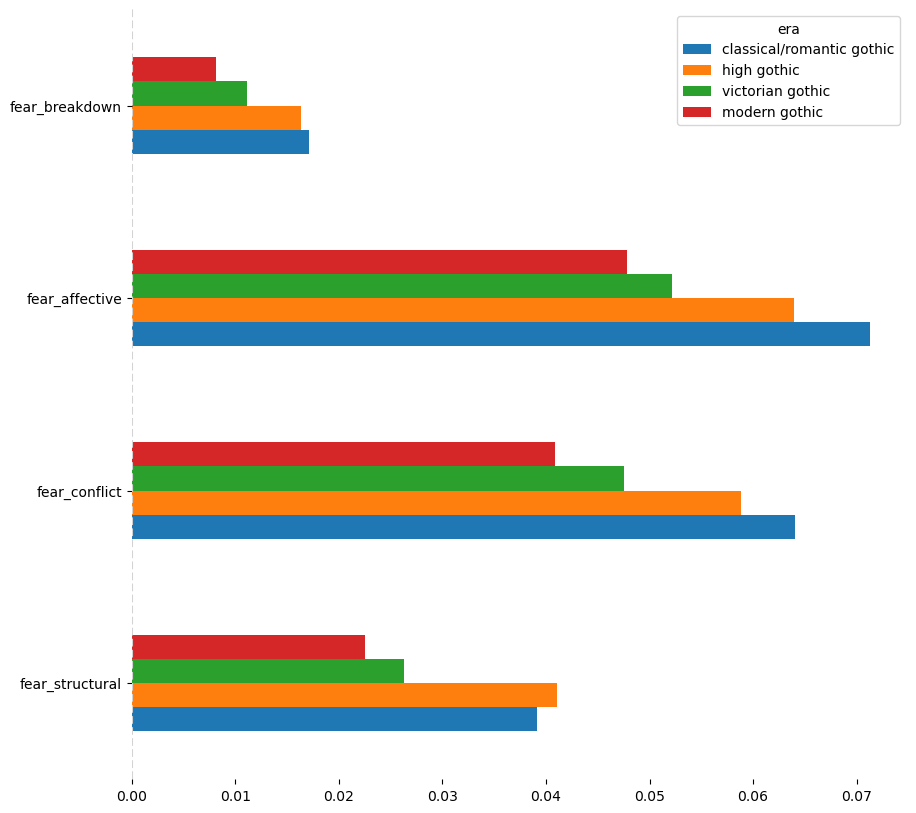

In [37]:
ax = DOC_SENT.T.plot.barh(figsize=(10,10))
ax.axvline(0, c='lightgray', ls='--')
sns.despine(left=True, bottom=True)
plt.show()

### Export tables

In [39]:
VOCAB_SENT.to_csv("data/VOCAB_SENT.csv", index=False)
BOW_SENT.to_csv("data/BOW_SENT.csv", index=False)
DOC_SENT.to_csv("data/DOC_SENT.csv")